---

### №3 **(4 балла)**

Выполните задания из файла https://cloud.mail.ru/public/c9bT/2T4A6yHUN

---

**УСЛОВИЕ**

Мы будем использовать в данном задании набор данных Boston, где нужно предсказать стоимость жилья на основе различных характеристик
расположения (загрязненность воздуха, близость к дорогам и т.д.). Подробнее о признаках можно почитать по адресу
https://archive.ics.uci.edu/ml/datasets/Housing

1. Загрузите выборку Boston с помощью функции sklearn.datasets.load_boston().
Результатом вызова данной функции является объект, у которого
признаки записаны в поле data, а целевой вектор — в поле target.

2. Приведите признаки в выборке к одному масштабу при помощи
функции sklearn.preprocessing.scale.

3. Переберите разные варианты параметра метрики p по сетке от 1 до
10 с таким шагом, чтобы всего было протестировано 200 вариантов
(используйте функцию numpy.linspace). Используйте KNeighborsRegressor
с n_neighbors=5 и weights=’distance’ — данный параметр добавляет
в алгоритм веса, зависящие от расстояния до ближайших соседей. В
качестве метрики качества используйте среднеквадратичную ошибку (параметр scoring=’mean_squared_error’ у cross_val_score; при
использовании библиотеки scikit-learn версии 18.0.1 и выше необходимо указывать scoring=’neg_mean_squared_error’). Качество оценивайте, как и в предыдущем задании, с помощью кросс-валидации
по 5 блокам с random_state = 42, не забудьте включить перемешивание выборки (shuffle=True).

4. Определите, при каком p качество на кросс-валидации оказалось
оптимальным. Обратите внимание, что cross_val_score возвраща2
ет массив показателей качества по блокам; необходимо максимизировать среднее этих показателей. Это значение параметра и будет
ответом на задачу.

Если ответом является нецелое число, то целую и дробную часть
необходимо разграничивать точкой, например, 0.4. При необходимости
округляйте дробную часть до одного знака.

---

**РЕШЕНИЕ**

In [10]:
# from sklearn.datasets import load_boston !! датасет удален в новой версии 
from keras.datasets import boston_housing
import pandas as pd
import numpy as np
from sklearn.preprocessing import scale
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

1. Загрузите выборку Boston с помощью функции sklearn.datasets.load_boston(). Результатом вызова данной функции является объект, у которого
признаки записаны в поле data, а целевой вектор — в поле target

In [11]:
# загрузка данных
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

# объединяем тренировочные и тестовые в один набор, чтобы имитировать load_boston
X = np.vstack([X_train, X_test])   # аналоги boston.data
y = np.hstack([y_train, y_test])   # аналог boston.target

print(X.shape, y.shape)

(506, 13) (506,)


**ПРИМЕЧАНИЕ:** 
- поскольку load_boston удалён в новой версии scikit‑learn, датасет Boston был загружен через модуль keras.datasets.boston_housing;
- матрица признаков X и целевой вектор y далее используются аналогично полям data и target объекта load_boston

2. Приведите признаки в выборке к одному масштабу при помощи
функции sklearn.preprocessing.scale.

In [12]:
# X — матрица признаков (объекты × признаки)
X_scaled = scale(X)

3. Переберите разные варианты параметра метрики p по сетке от 1 до
10 с таким шагом, чтобы всего было протестировано 200 вариантов
(используйте функцию numpy.linspace). Используйте KNeighborsRegressor
с n_neighbors=5 и weights=’distance’ — данный параметр добавляет
в алгоритм веса, зависящие от расстояния до ближайших соседей. В
качестве метрики качества используйте среднеквадратичную ошибку (параметр scoring=’mean_squared_error’ у cross_val_score; при
использовании библиотеки scikit-learn версии 18.0.1 и выше необходимо указывать scoring=’neg_mean_squared_error’). Качество оценивайте, как и в предыдущем задании, с помощью кросс-валидации
по 5 блокам с random_state = 42, не забудьте включить перемешивание выборки (shuffle=True).

In [13]:
# 1. Создаём сетку от 1 до 10 с 200 точками
p_values = np.linspace(1, 10, 200)

# 2. Настраиваем кросс-валидацию
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Перебираем значения p и считаем качество
mse_scores = []

for p in p_values:
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance', p=p)
    
    # cross_val_score возвращает neg_mean_squared_error (отрицательные значения)
    scores = cross_val_score(knn, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
    
    # берём среднее по фолдам
    mse_scores.append(scores.mean())

# 4. Находим оптимальное значение p (максимум neg_MSE = минимум MSE)
best_idx = np.argmax(mse_scores)
best_p = p_values[best_idx]
best_mse = -mse_scores[best_idx]  # переводим обратно в положительное MSE

print(f"Оптимальное значение p: {best_p:.4f}")
print(f"Минимальная MSE: {best_mse:.4f}")

Оптимальное значение p: 1.2714
Минимальная MSE: 16.1547


4. Определите, при каком p качество на кросс-валидации оказалось
оптимальным. Обратите внимание, что cross_val_score возвращает массив показателей качества по блокам; необходимо максимизировать среднее этих показателей. Это значение параметра и будет
ответом на задачу.

In [14]:
# Находим индекс максимального среднего neg_MSE
best_idx = np.argmax(mse_scores)
optimal_p = p_values[best_idx]

print(f"Оптимальное значение параметра p: {optimal_p:.4f}")

Оптимальное значение параметра p: 1.2714


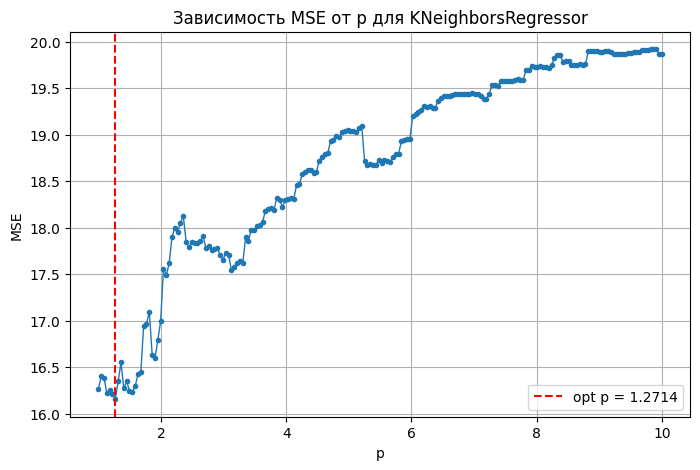

In [15]:
# переведём neg_MSE в обычный MSE
mse_positive = [-score for score in mse_scores]

plt.figure(figsize=(8, 5))
plt.plot(p_values, mse_positive, marker='.', linewidth=1)
plt.axvline(optimal_p, color='red', linestyle='--', label=f'opt p = {optimal_p:.4f}')
plt.xlabel('p')
plt.ylabel('MSE')
plt.title('Зависимость MSE от p для KNeighborsRegressor')
plt.legend()
plt.grid(True)
plt.show()

**ПОЯСНЕНИЕ:**
- по графику видим что ошибка действительно минимальна в данной точке